
## kNN. Линейные модели. Работа с признаками.

Визуализация решающих поверхностей в kNN.

Загрузим набор данных и сохраним информацию о признаках в переменную `X`, а о зависимой переменной – в переменную `y`.

In [1]:
from pdb import find_function

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.datasets import load_wine

data = load_wine()
X = pd.DataFrame(data['data'], columns = data['feature_names'])
y = data['target']
X.head(8)
X_knn = X[['alcohol', 'magnesium']]
data

{'data': array([[1.423e+01, 1.710e+00, 2.430e+00, ..., 1.040e+00, 3.920e+00,
         1.065e+03],
        [1.320e+01, 1.780e+00, 2.140e+00, ..., 1.050e+00, 3.400e+00,
         1.050e+03],
        [1.316e+01, 2.360e+00, 2.670e+00, ..., 1.030e+00, 3.170e+00,
         1.185e+03],
        ...,
        [1.327e+01, 4.280e+00, 2.260e+00, ..., 5.900e-01, 1.560e+00,
         8.350e+02],
        [1.317e+01, 2.590e+00, 2.370e+00, ..., 6.000e-01, 1.620e+00,
         8.400e+02],
        [1.413e+01, 4.100e+00, 2.740e+00, ..., 6.100e-01, 1.600e+00,
         5.600e+02]], shape=(178, 13)),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [3]:
# нет категориальных переменных
X.info()
# нет пропущенных значений
X.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
dtypes: float64(13)
m

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
dtype: int64

In [4]:
from sklearn.model_selection import train_test_split
np.random.seed(13)
X_train, X_test, y_train, y_test = train_test_split(X_knn, y, test_size=0.3)

In [5]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)
clf1 = KNeighborsClassifier(n_neighbors=1, metric='euclidean', p=2)
clf2 = KNeighborsClassifier(n_neighbors=3, metric='euclidean', p=2)
clf3 = KNeighborsClassifier(n_neighbors=5, metric='euclidean', p=2)
clf4 = KNeighborsClassifier(n_neighbors=10, metric='euclidean', p=2)
clf5 = KNeighborsClassifier(n_neighbors=15, metric='euclidean', p=2)
clf6 = KNeighborsClassifier(n_neighbors=25, metric='euclidean', p=2)
features = ['alcohol', 'magnesium']
clf1.fit(X_train_scaled, y_train)
clf_1_y_predicted_train = clf1.predict(X_train_scaled)
clf_1_y_predicted_test = clf1.predict(X_test_scaled)
clf2.fit(X_train_scaled, y_train)
clf_2_y_predicted_train = clf2.predict(X_train_scaled)
clf_2_y_predicted_test = clf2.predict(X_test_scaled)
clf3.fit(X_train_scaled, y_train)
clf_3_y_predicted_train = clf3.predict(X_train_scaled)
clf_3_y_predicted_test = clf3.predict(X_test_scaled)
clf4.fit(X_train_scaled, y_train)
clf_4_y_predicted_train = clf4.predict(X_train_scaled)
clf_4_y_predicted_test = clf4.predict(X_test_scaled)
clf5.fit(X_train_scaled, y_train)
clf_5_y_predicted_train = clf5.predict(X_train_scaled)
clf_5_y_predicted_test = clf5.predict(X_test_scaled)
clf6.fit(X_train_scaled, y_train)
clf_6_y_predicted_train = clf6.predict(X_train_scaled)
clf_6_y_predicted_test = clf6.predict(X_test_scaled)
print("clf 1's Accuracy on train is: ", np.mean(y_train == clf_1_y_predicted_train))
print("clf 1's Accuracy on test is: ", np.mean(y_test == clf_1_y_predicted_test))
print("clf 2's Accuracy on train is: ", np.mean(y_train == clf_2_y_predicted_train))
print("clf 2's Accuracy on test is: ", np.mean(y_test == clf_2_y_predicted_test))
print("clf 3's Accuracy on train is: ", np.mean(y_train == clf_3_y_predicted_train))
print("clf 3's Accuracy on test is: ", np.mean(y_test == clf_3_y_predicted_test))
print("clf 4's Accuracy on train is: ", np.mean(y_train == clf_4_y_predicted_train))
print("clf 4's Accuracy on test is: ", np.mean(y_test == clf_4_y_predicted_test))
print("clf 5's Accuracy on train is: ", np.mean(y_train == clf_5_y_predicted_train))
print("clf 5's Accuracy on test is: ", np.mean(y_test == clf_5_y_predicted_test))
print("clf 6's Accuracy on train is: ", np.mean(y_train == clf_6_y_predicted_train))
print("clf 6's Accuracy on test is: ", np.mean(y_test == clf_6_y_predicted_test))

clf 1's Accuracy on train is:  1.0
clf 1's Accuracy on test is:  0.7037037037037037
clf 2's Accuracy on train is:  0.8145161290322581
clf 2's Accuracy on test is:  0.7592592592592593
clf 3's Accuracy on train is:  0.7983870967741935
clf 3's Accuracy on test is:  0.7222222222222222
clf 4's Accuracy on train is:  0.7741935483870968
clf 4's Accuracy on test is:  0.6666666666666666
clf 5's Accuracy on train is:  0.7903225806451613
clf 5's Accuracy on test is:  0.6851851851851852
clf 6's Accuracy on train is:  0.7258064516129032
clf 6's Accuracy on test is:  0.6481481481481481


In [6]:
! pip install mlxtend --user


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Can not perform a '--user' install. User site-packages are not visible in this virtualenv.


In [7]:
import mlxtend

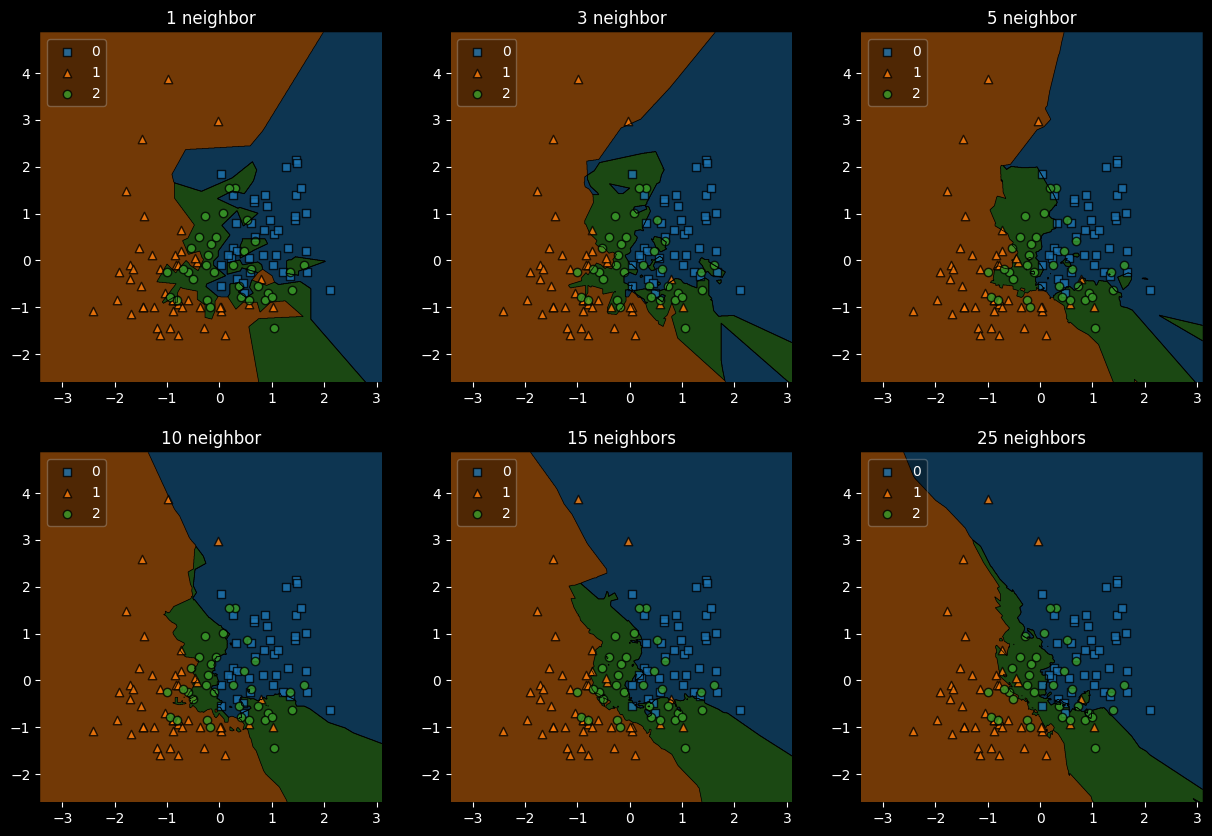

numpy.ndarray

In [8]:
import matplotlib.pyplot as plt
from mlxtend.plotting import plot_decision_regions
import matplotlib.gridspec as gridspec
import itertools
labels = ['1 neighbor', '3 neighbor', '5 neighbor', '10 neighbor', '15 neighbors', '25 neighbors']
positions = list(itertools.product([0, 1], [0, 1, 2]))
gs = gridspec.GridSpec(2, 3)

fig = plt.figure(figsize=(15,10))
for clf, lab, grd in zip([clf1, clf2, clf3, clf4, clf5, clf6],
                         labels,
                         list(itertools.product([0, 1], [0, 1, 2]))):

    clf.fit(X_train_scaled, y_train)
    ax = plt.subplot(gs[grd[0], grd[1]])
    fig = plot_decision_regions(X=X_train_scaled, y=y_train, clf=clf, legend=2)
    plt.title(lab)

plt.show()
type(X_train_scaled)

In [9]:
# С точки зрения геометрии данных число соседей 15 считаю наиболее оптимальным.
# clf1 явное переобучение, clf2 лучше, но там странные оторванные зелёные зоны, 5 тоже с оторванными зонами, 10 две оторванные зелёные зоны, 25 даёт странную тонкую зелёную полосу сверху, где данных нет

## KNN своими руками


В данном задании мы попробуем реализовать алгоритм KNN своими руками. В данном случае мы попробуем сделать KNN для классификации.

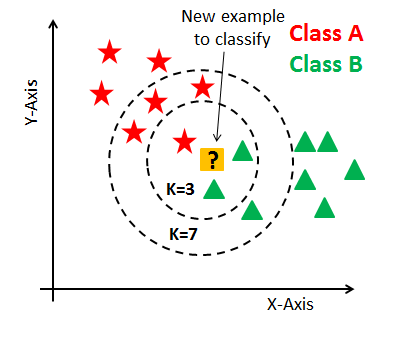

In [10]:
import numpy as np
from collections import Counter
from sklearn.base import BaseEstimator

class KNN(BaseEstimator):
    def __init__(self, k:int):
        self.k = k

    def fit(self, X, y):
      # YOUR CODE HERE
      self.X_train = X
      self.y_train = y
      return self

    def predict(self, X):
      # YOUR CODE HERE
      pred = []
      for x in X:
        distances = np.sqrt(np.sum((self.X_train - x)**2, axis=1))
        k_indices = np.argsort(distances)[:self.k]
        k_labels = self.y_train[k_indices]
        most_common = Counter(k_labels).most_common(1)[0][0]
        pred.append(most_common)
      return np.array(pred)

In [11]:
# Не меняйте файл!
def test_knn(KNN):
  knn = KNN(k=1)
  X_train =  np.array([[1, 1], [2, 2]])
  y_train =  np.array([0, 1])
  X_test =  np.array([[1.5, 1.5]])
  knn.fit(X_train, y_train)
  assert knn.predict(X_test) == [0]

  knn = KNN(k=3)
  X_train = np.array([[1, 1], [2, 2], [3, 3], [4, 4], [5, 5], [6, 6], [7, 7], [8, 8], [9, 9], [10, 10]])
  y_train = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
  X_test = np.array([[9.5, 9.5]])
  knn.fit(X_train, y_train)
  assert knn.predict(X_test) == [1]

  knn = KNN(k=3)
  X_train = np.array([[1, 1], [2, 2], [3, 3], [4, 4], [5, 5], [6, 6], [7, 7], [8, 8], [9, 9], [10, 10]])
  y_train = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
  X_test = np.array([[5.5, 5.5]])
  knn.fit(X_train, y_train)
  assert knn.predict(X_test) == [1]

  knn = KNN(k=3)
  X_train = np.array([[1, 1], [2, 2], [3, 3], [4, 4], [5, 5], [6, 6], [7, 7], [8, 8], [9, 9], [10, 10]])
  y_train = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
  X_test = np.array([[15, 15]])
  knn.fit(X_train, y_train)
  assert knn.predict(X_test) == [1]

  knn = KNN(k=3)
  X_train = np.array([[1, 1], [2, 2], [3, 3], [4, 4], [5, 5], [6, 6], [7, 7], [8, 8], [9, 9], [10, 10]])
  y_train = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
  X_test = np.array([[5, 5], [2, 2]])
  knn.fit(X_train, y_train)
  assert all(knn.predict(X_test) == [1, 0])

In [12]:

test_knn(KNN)


## Линейная регрессия своими руками.

В этом задании мы попробуем реализовать алгоритм линейной регрессии своими руками и рассмотрим различные аспекты построения линейной модели. Мы будем работать с одним из классических наборов данных в статистике, содержащим информацию о бриллиантах. Описание можно посмотреть [здесь](https://www.kaggle.com/shivam2503/diamonds).

In [13]:
import kagglehub
import pandas as pd
# Загружаем последнюю версию
path = kagglehub.dataset_download("shivam2503/diamonds")

print("Path to dataset files:", path)

C:\Users\user\PycharmProjects\ML дз 1\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\user\.cache\kagglehub\datasets\shivam2503\diamonds\versions\1


In [15]:
data = pd.read_csv(path + '/' + 'diamonds.csv', index_col=0)
data.head(5)

,carat,cut,color,clarity,depth,table,price,x,y,z
1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


Мы будем решать задачу на примере предсказания цены бриллианта `price` в зависимости от его характеристик.

In [16]:
# Аналитический способ

import numpy as np
from sklearn.base import BaseEstimator

class Linreg_an(BaseEstimator):
    def fit(self, X, y):
      # YOUR CODE HERE
      X_with_bias = np.c_[np.ones(X.shape[0]), X]
      self.w = np.linalg.inv(X_with_bias.T @ X_with_bias) @ X_with_bias.T @ y
      return self

    def predict(self, X):
        X_with_bias = np.c_[np.ones(X.shape[0]), X]
        return X_with_bias @ self.w

In [17]:
# Численный (через градиентный спуск) способ

import numpy as np
from sklearn.base import BaseEstimator

class Linreg_grad(BaseEstimator):
    def fit(self, X, y):
      X_with_bias = np.c_[np.ones(X.shape[0]), X]
      weights = np.zeros(X_with_bias.shape[1])
      eps = 0.1
      grad = (2 / X_with_bias.shape[0]) * (X_with_bias.T @ (X_with_bias @ weights - y))
      lr = 0.001
      iteration = 0
      while np.linalg.norm(grad) > eps and iteration < 10000:
          weights = weights - lr * grad
          grad = (2 / X_with_bias.shape[0]) * (X_with_bias.T @ (X_with_bias @ weights - y))
          iteration = iteration + 1
      self.w = weights
      return self


    def predict(self, X):
      # YOUR CODE HERE
      X_with_bias = np.c_[np.ones(X.shape[0]), X]
      return X_with_bias @ self.w

# Проверка на простых данных
X = np.array([[1, 2], [3, 4], [5, 6]])
y = np.array([10, 20, 30])

model = Linreg_grad()
model.fit(X, y)

predictions = model.predict(X)
print(f"Предсказания: {predictions}")
print(f"Реальные y: {y}")
print(f"Ошибка: {np.mean((predictions - y)**2)}")
print(f"Веса (bias, w1, w2): {model.w}")

Предсказания: [ 9.8497704  19.96002546 30.07028052]
Реальные y: [10 20 30]
Ошибка: 0.009702082471268497
Веса (bias, w1, w2): [1.51138607 1.77187073 3.2832568 ]


In [18]:
# пропущенных значений нет
data.isna().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

In [19]:
# нет константных столбцов
n_unique = data.nunique()
n_unique

carat        273
cut            5
color          7
clarity        8
depth        184
table        127
price      11602
x            554
y            552
z            375
dtype: int64

In [20]:
features = ['carat', 'depth', 'table', 'x', 'y', 'z', 'price']
data_corr = data[features]
correlations = data_corr.corrwith(data_corr['price']).sort_values(ascending=False)
correlations
# больше всего коррелирует carat, x, y, z

price    1.000000
carat    0.921591
x        0.884435
y        0.865421
z        0.861249
table    0.127134
depth   -0.010647
dtype: float64

In [21]:
data = pd.get_dummies(data, columns = ['cut', 'color', 'clarity'], dtype=int)

In [22]:
X = data.drop('price', axis=1)
y = data['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 1 to 53940
Data columns (total 26 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   carat          53940 non-null  float64
 1   depth          53940 non-null  float64
 2   table          53940 non-null  float64
 3   x              53940 non-null  float64
 4   y              53940 non-null  float64
 5   z              53940 non-null  float64
 6   cut_Fair       53940 non-null  int64  
 7   cut_Good       53940 non-null  int64  
 8   cut_Ideal      53940 non-null  int64  
 9   cut_Premium    53940 non-null  int64  
 10  cut_Very Good  53940 non-null  int64  
 11  color_D        53940 non-null  int64  
 12  color_E        53940 non-null  int64  
 13  color_F        53940 non-null  int64  
 14  color_G        53940 non-null  int64  
 15  color_H        53940 non-null  int64  
 16  color_I        53940 non-null  int64  
 17  color_J        53940 non-null  int64  
 18  clarity_I1     53

In [23]:
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [24]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
mod1 = Linreg_an()
mod2 = Linreg_grad()



mod1.fit(X_train_scaled, y_train)
mod2.fit(X_train_scaled, y_train)

pred1_train = mod1.predict(X_train_scaled)
pred1_test = mod1.predict(X_test_scaled)
pred2_train = mod2.predict(X_train_scaled)
pred2_test = mod2.predict(X_test_scaled)

mse_1_train = mean_squared_error(y_train, pred1_train)
mse_1_test = mean_squared_error(y_test, pred1_test)
mse_2_train = mean_squared_error(y_train, pred2_train)
mse_2_test = mean_squared_error(y_test, pred2_test)
print(f"Аналитическая регрессия, train {mse_1_train}")
print(f"Аналитическая регрессия, test {mse_1_test}")
print(f"Градиентный спуск, train {mse_2_train}")
print(f"Градиентный спуск, test {mse_2_test}")
X.info()

Аналитическая регрессия, train 1274735.2389880454
Аналитическая регрессия, test 1320211.570946479
Градиентный спуск, train 1452548.6472517368
Градиентный спуск, test 1458108.875162376
<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 1 to 53940
Data columns (total 26 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   carat          53940 non-null  float64
 1   depth          53940 non-null  float64
 2   table          53940 non-null  float64
 3   x              53940 non-null  float64
 4   y              53940 non-null  float64
 5   z              53940 non-null  float64
 6   cut_Fair       53940 non-null  int64  
 7   cut_Good       53940 non-null  int64  
 8   cut_Ideal      53940 non-null  int64  
 9   cut_Premium    53940 non-null  int64  
 10  cut_Very Good  53940 non-null  int64  
 11  color_D        53940 non-null  int64  
 12  color_E        53940 non-null  int64  
 13  color_F        53940 non-null  int64  
 14  color_G  

In [25]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_scaled, y_train)

print("Коэффициенты (веса):", model.coef_)
no_regr = pd.DataFrame({
    'no_regr_coef': model.coef_
})
# сильно отличаются веса для carat и z, что ожидаемо с точки зрения матриц корреляций

Коэффициенты (веса): [ 5.40143550e+03 -9.29095504e+01 -6.55090630e+01 -1.20655510e+03
  1.35885170e+01 -2.28060524e+01 -1.24687073e+02 -3.77932547e+01
  4.66316756e+01  1.75296657e+01  2.91770547e+00  2.06887416e+02
  1.64108892e+02  1.37361619e+02  6.19957187e+01 -1.27402415e+02
 -2.50249123e+02 -3.93712209e+02 -4.49016967e+02  2.40806619e+02
 -1.48285968e+02 -4.97068813e+02  2.01106933e+02  1.07131937e+02
  2.46073191e+02  2.70577792e+02]


Насколько сильно проблема мультиколлинеарности проявлялась в изначальной регрессии. Кто агрессивнее уменьшает веса?

In [ ]:
from sklearn.linear_model import Ridge, Lasso
ridge = Ridge(alpha=10)
ridge.fit(X_train_scaled, y_train)

ridge_weights = pd.DataFrame({
    'ridge_coef': ridge.coef_
})

lasso = Lasso(alpha=10)
lasso.fit(X_train_scaled, y_train)

lasso_weights = pd.DataFrame({
    'lasso_coef': lasso.coef_
})
coeff = pd.merge(ridge_weights, lasso_weights, left_index=True, right_index=True)
coeff = pd.merge(coeff, no_regr, left_index=True, right_index=True)
coeff
# веса явно уменьшились в lasso, в ridge особых изменений нет. Мультиколлинеарность была и lasso оказался более эффективен

Подбор альфа для Lasso


In [28]:
from sklearn.linear_model import LassoCV
alphas = [0.1, 1, 10, 100, 200]
lasso_cv = LassoCV(
    alphas=alphas,
    cv=5,
    max_iter=10000,
    random_state=42
)
lasso_cv.fit(X_train_scaled, y_train)
mean_mse = np.mean(lasso_cv.mse_path_, axis=1)
results = pd.DataFrame({
    'alpha': lasso_cv.alphas_,
    'mean_mse': mean_mse,
})
results = results.sort_values('mean_mse')
print(results)
# наибольшее качество даёт alpha = 1
# X.info()

   alpha      mean_mse
3    1.0  1.266676e+06
4    0.1  1.267343e+06
2   10.0  1.277572e+06
1  100.0  1.524308e+06
0  200.0  1.940018e+06


In [29]:
lasso = Lasso(alpha=1, random_state=42)
lasso.fit(X_train_scaled, y_train)

lasso_weights = pd.DataFrame({
    'lasso_coef': lasso.coef_
})
lasso_weights
# многие категориальные признаки получили нулевые веса, но не все. некоторое категориальные признаки напротив получили сравнительно большие веса, что может указывать на то, что влияние каких-то конкретных конфигураций алмазов сильно влияет на цену. также по матрице корреляций ожидаемо, что carat имеет большой ненулевой вес

,lasso_coef
0,5355.760448
1,-90.009734
2,-64.132558
3,-1150.755553
4,-0.000000
5,-21.651150
6,-130.833171
7,-48.171979
8,28.139449
9,0.000000


Какую модель лучше использовать для предсказаний?

In [30]:

mod1.fit(X_train_scaled, y_train)
mod2.fit(X_train_scaled, y_train)
pred1_test = mod1.predict(X_test_scaled)

pred2_test = mod2.predict(X_test_scaled)
pred3_test = lasso.predict(X_test_scaled)

mse_1_test = mean_squared_error(y_test, pred1_test)

mse_2_test = mean_squared_error(y_test, pred2_test)
mse_3_test = mean_squared_error(y_test, pred3_test)
print(f"Аналитическая регрессия, test {mse_1_test}")

print(f"Градиентный спуск, test {mse_2_test}")

print(f"Lasso, test {mse_3_test}")
print(f"Lasso, test mae {mean_absolute_error(y_test, pred3_test)}")
# Судя по данным MSE лучше всего использвать Lasso. Возможно данные всё-таки подвержены мультикоррелированности и Lasso занулило веса признакам, которые не были значительными для параметра price. В то же время успех аналитического решения может объясняться тем, что все данные устроены примерно одинаково и тестовые тем самым хорошо описываются аналитическим решением

Аналитическая регрессия, test 1320211.570946479
Градиентный спуск, test 1458108.875162376
Lasso, test 1310901.0844821278
Lasso, test mae 738.0856669258275
